In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

In [ ]:
df = pd.read_csv('/content/refined_dataset.csv')

In [ ]:
df_new = df.copy()

df_new = df.copy()

# Basic transformations
df_new['log_matrixSize'] = np.log1p(df['matrixSize'])
df_new['matrixSize_squared'] = df['matrixSize'] ** 2

# Ratio features
df_new['computation_density'] = df['numOp'] / (df['matrixSize'] ** 2)
df_new['time_per_op'] = df['exeTime'] / np.maximum(df['numOp'], 1)  # Avoid division by zero

# Interaction features
df_new['size_complexity'] = df['matrixSize'] * df['complexity']
df_new['op_complexity'] = df['numOp'] * df['complexity']
df_new['memory_complexity'] = df['memoryPattern'] * df['complexity']

# Domain-specific features
df_new['flops_estimate'] = df['complexity'] * (df['matrixSize'] ** 2) * df['numOp']
df_new['memory_footprint'] = df['matrixSize'] ** 2 * df['numVar']

# Algorithm specific
df_new['iterative_complexity'] = df['isIterative'] * df['complexity']

# Categorical encoding - One-hot encode typeOp
encoder = OneHotEncoder(sparse_output=False, drop='first')
#type_encoded = encoder.fit_transform(df[['typeOp']])
#type_columns = [f'typeOp_{cat}' for cat in encoder.categories_[0][1:]]

# Add encoded columns to dataframe
for i, col in enumerate(type_columns):
    df_new[col] = type_encoded[:, i]

df_engineered=df_new

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
X = df_engineered.drop(['optimalThreads', 'typeOp'], axis=1)  # Remove original categorical and target
y = df_engineered['optimalThreads']

KeyError: "['typeOp'] not found in axis"

In [ ]:
# Identify columns with object (string) dtype
object_cols = X.select_dtypes(include=['object']).columns

# Convert object columns to numerical using OneHotEncoding
for col in object_cols:
    # Create OneHotEncoder instance for each column
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # handle_unknown='ignore' for unseen values in test data

    # Fit and transform the column
    encoded_data = encoder.fit_transform(X[[col]])

    # Get feature names for the encoded columns
    feature_names = encoder.get_feature_names_out([col])

    # Create a DataFrame with encoded data and feature names
    encoded_df = pd.DataFrame(encoded_data, columns=feature_names, index=X.index)

    # Drop the original column and add the encoded columns
    X = X.drop(columns=[col])
    X = pd.concat([X, encoded_df], axis=1)

# Now fit the selector with the numerically encoded data
selector = SelectFromModel(
    RandomForestRegressor(n_estimators=100, random_state=42),
    threshold='median'
)
selector.fit(X, y)

# Get selected feature indices
selected_features = X.columns[selector.get_support()]

print(f"Selected {len(selected_features)} features out of {X.shape[1]}")
print("Selected features:", selected_features.tolist())

X_selected = X[selected_features]

Selected 15 features out of 29
Selected features: ['matrixSize', 'numOp', 'exeTime', 'matrixType', 'log_matrixSize', 'matrixSize_squared', 'time_per_op', 'size_complexity', 'op_complexity', 'flops_estimate', 'memory_footprint', 'typeOp_Logarithm', 'typeOp_Multiplication', 'varType_int', 'varType_mixed']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')  # Or other strategies like 'median', 'most_frequent'

# Fit and transform on training data, then transform on testing data
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Models to try
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(random_state=42),
    "Neural Network": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

results = {}

# Train and evaluate each model
for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Round predictions to nearest integer (as thread count should be integer)
    y_pred_rounded = np.round(y_pred)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred_rounded)
    r2 = r2_score(y_test, y_pred_rounded)
    accuracy = np.mean(y_pred_rounded == y_test)

    results[name] = {
        "MSE": mse,
        "R2": r2,
        "Accuracy": accuracy,
        "Model": model
    }

    print(f"{name} - MSE: {mse:.4f}, R2: {r2:.4f}, Accuracy: {accuracy:.4f}")


Random Forest - MSE: 1.8077, R2: 0.6712, Accuracy: 0.4727
Gradient Boosting - MSE: 1.8806, R2: 0.6579, Accuracy: 0.3310
XGBoost - MSE: 1.6791, R2: 0.6945, Accuracy: 0.4453
Neural Network - MSE: 2.0364, R2: 0.6296, Accuracy: 0.3735


In [ ]:
best_model_name = max(results, key=lambda k: results[k]['Accuracy'])
print(f"Best model: {best_model_name} with accuracy: {results[best_model_name]['Accuracy']:.4f}")

Best model: Random Forest with accuracy: 0.4727


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter grids for different models
param_grids = {
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    },
    "XGBoost": {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    },
    "Neural Network": {
        'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate_init': [0.001, 0.01]
    }
}

# Select the model and parameter grid
if best_model_name == "Random Forest":
    model = RandomForestRegressor(random_state=42)
elif best_model_name == "XGBoost":
    model = xgb.XGBRegressor(random_state=42)
elif best_model_name == "Neural Network":
    model = MLPRegressor(max_iter=1000, random_state=42)
else:
    model = GradientBoostingRegressor(random_state=42)
    param_grids["Gradient Boosting"] = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    }

param_grid = param_grids.get(best_model_name)

# Perform grid search
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

# Best parameters and model
print(f"Best parameters for {best_model_name}:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# Evaluate on test set
y_pred = best_model.predict(X_test_scaled)
y_pred_rounded = np.round(y_pred)

mse = mean_squared_error(y_test, y_pred_rounded)
r2 = r2_score(y_test, y_pred_rounded)
accuracy = np.mean(y_pred_rounded == y_test)

print(f"Tuned {best_model_name} - MSE: {mse:.4f}, R2: {r2:.4f}, Accuracy: {accuracy:.4f}")


Best parameters for Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Random Forest - MSE: 1.6134, R2: 0.7065, Accuracy: 0.4443


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
file_path = "/content/matrix_operations_dataset.csv"
df = pd.read_csv(file_path)

# Encode categorical variable 'operation'
label_encoder = LabelEncoder()
df['operation_encoded'] = label_encoder.fit_transform(df['operation'])

# Select features and target
features = ['operation_encoded', 'matrix_size', 'variable_type', 'num_operations']
target = 'optimal_thread'

# Normalize numerical features
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42, stratify=df[target])

# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model from GridSearch
best_rf_model = grid_search.best_estimator_
y_pred_best = best_rf_model.predict(X_test)

# Final evaluation
best_accuracy = accuracy_score(y_test, y_pred_best)
print(f"\nBest Model Accuracy After Tuning: {best_accuracy:.4f}")
print("Best Model Parameters:", grid_search.best_params_)
print("Final Classification Report:\n", classification_report(y_test, y_pred_best))


Model Accuracy: 0.4601

Classification Report:
               precision    recall  f1-score   support

           1       0.62      0.75      0.68       178
           2       0.31      0.18      0.23       141
           4       0.41      0.44      0.42       332
           8       0.51      0.50      0.50       421
          16       0.28      0.27      0.28       132

    accuracy                           0.46      1204
   macro avg       0.43      0.43      0.42      1204
weighted avg       0.45      0.46      0.45      1204


Best Model Accuracy After Tuning: 0.5042
Best Model Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Final Classification Report:
               precision    recall  f1-score   support

           1       0.60      0.83      0.70       178
           2       0.31      0.15      0.20       141
           4       0.43      0.50      0.46       332
           8       0.56      0.61      0.58       421
          

Best Random Forest Accuracy: 0.4958
XGBoost Accuracy: 0.4676

Random Forest Classification Report:
               precision    recall  f1-score   support

           1       0.59      0.79      0.68       178
           2       0.34      0.15      0.21       141
           4       0.43      0.54      0.48       332
           8       0.55      0.56      0.56       421
          16       0.32      0.14      0.20       132

    accuracy                           0.50      1204
   macro avg       0.45      0.44      0.42      1204
weighted avg       0.47      0.50      0.47      1204


XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.23      0.12      0.15       178
           2       0.15      0.38      0.21       141
           3       0.00      0.00      0.00         0
           4       0.20      0.05      0.09       332
           8       0.00      0.00      0.00       421

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

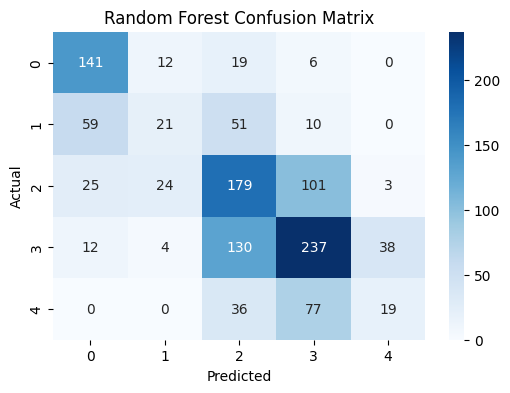

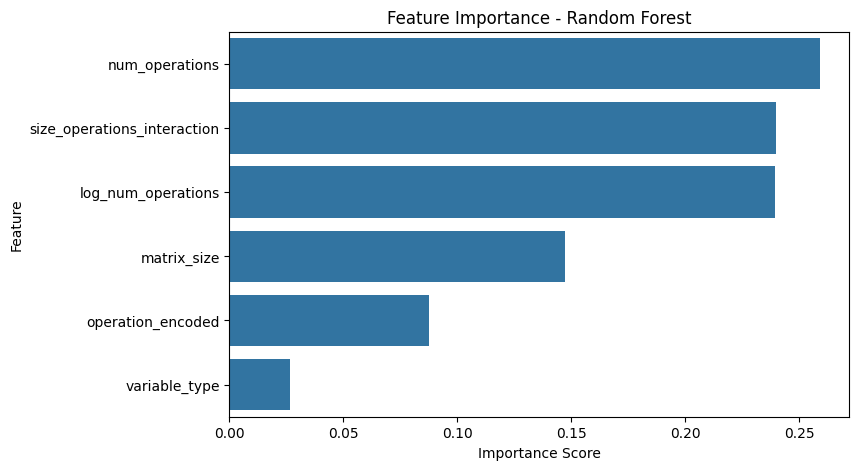

(0.4958471760797342, 0.4676079734219269)

In [ ]:
# Re-import necessary libraries
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Reload the dataset
df = pd.read_csv("/content/matrix_operations_dataset.csv")

# Encode categorical variable 'operation'
label_encoder = LabelEncoder()
df['operation_encoded'] = label_encoder.fit_transform(df['operation'])

# Feature Engineering: Add interaction terms
df['size_operations_interaction'] = df['matrix_size'] * df['num_operations']
df['log_num_operations'] = np.log1p(df['num_operations'])  # Log transformation

# Select new feature set
features = ['operation_encoded', 'matrix_size', 'variable_type', 'num_operations', 'size_operations_interaction', 'log_num_operations']
target = 'optimal_thread'

# Normalize new features
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42, stratify=df[target])

# Define Random Forest hyperparameter tuning
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize and run RandomizedSearchCV for Random Forest
rf_random_search = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_params, n_iter=10, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
rf_random_search.fit(X_train, y_train)

# Best Random Forest Model
best_rf_model = rf_random_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)
best_rf_accuracy = accuracy_score(y_test, y_pred_best_rf)
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Fit the encoder on the training target data
label_encoder.fit(y_train)

# Transform both the training and test target data
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
# Train XGBoost Model
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=10, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train_encoded)

# Evaluate XGBoost
y_pred_xgb = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test_encoded, y_pred_xgb)

# Print Accuracy Scores
print(f"Best Random Forest Accuracy: {best_rf_accuracy:.4f}")
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

# Print Classification Report
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_best_rf))
print("\nXGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))

# Confusion Matrix for Random Forest
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance for Random Forest
feature_importances = pd.Series(best_rf_model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# Return accuracy scores
best_rf_accuracy, xgb_accuracy


# Task
can you generate random forest code for this dataset

Here is all the data you need:
"matrix_operations_processed.csv"

## Data loading

### Subtask:
Load the dataset "matrix_operations_processed.csv" into a pandas DataFrame.


**Reasoning**:
Load the dataset "matrix_operations_processed.csv" into a pandas DataFrame.



In [ ]:
import pandas as pd

try:
    df = pd.read_csv('matrix_operations_processed.csv')
    display(df.head())
except FileNotFoundError:
    print("Error: 'matrix_operations_processed.csv' not found.")
    df = None
except pd.errors.EmptyDataError:
    print("Error: 'matrix_operations_processed.csv' is empty.")
    df = None
except pd.errors.ParserError:
    print("Error: 'matrix_operations_processed.csv' parsing error.")
    df = None
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df = None

,operation,matrix_size,variable_type,num_operations,optimal_thread,operation_encoded,size_operations_interaction,log_num_operations
0,addition,100,0,10000,1,0,1000000,9.210440
1,duplication,100,0,10000,1,1,1000000,9.210440
2,multiplication,100,0,1631010,8,3,163101000,14.304711
3,elemwise_multiplication,100,0,10000,1,2,1000000,9.210440
4,addition,100,1,10000,1,0,1000000,9.210440


## Data exploration

### Subtask:
Explore the loaded dataset to understand its structure, identify the target variable, and gain insights into the features.


**Reasoning**:
I need to explore the dataset by examining data types, missing values, summary statistics, and distributions of features. I will also identify the target variable and analyze relationships between features.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6018 entries, 0 to 6017
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   operation                    6018 non-null   object 
 1   matrix_size                  6018 non-null   int64  
 2   variable_type                6018 non-null   int64  
 3   num_operations               6018 non-null   int64  
 4   optimal_thread               6018 non-null   int64  
 5   operation_encoded            6018 non-null   int64  
 6   size_operations_interaction  6018 non-null   int64  
 7   log_num_operations           6018 non-null   float64
dtypes: float64(1), int64(6), object(1)
memory usage: 376.3+ KB
None
operation                      0
matrix_size                    0
variable_type                  0
num_operations                 0
optimal_thread                 0
operation_encoded              0
size_operations_interaction    0
log_num_operat

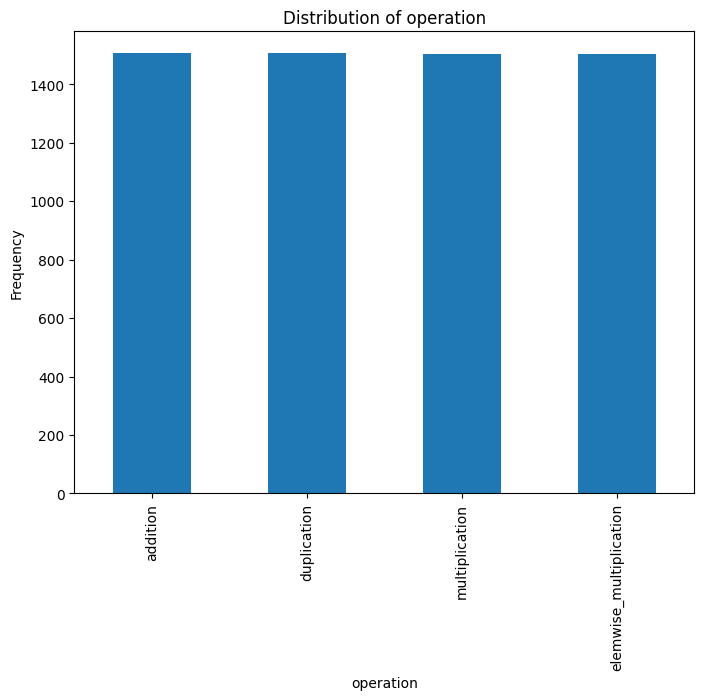


Value counts for variable_type:
variable_type
0    3010
1    3008
Name: count, dtype: int64


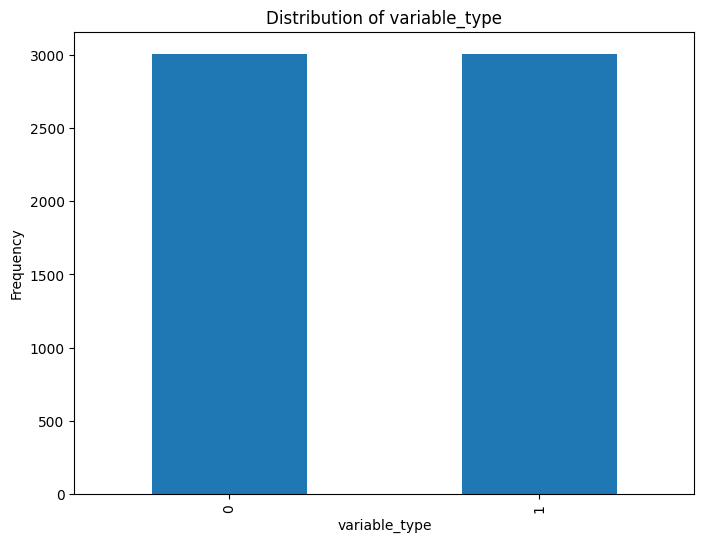


Target Variable: optimal_thread


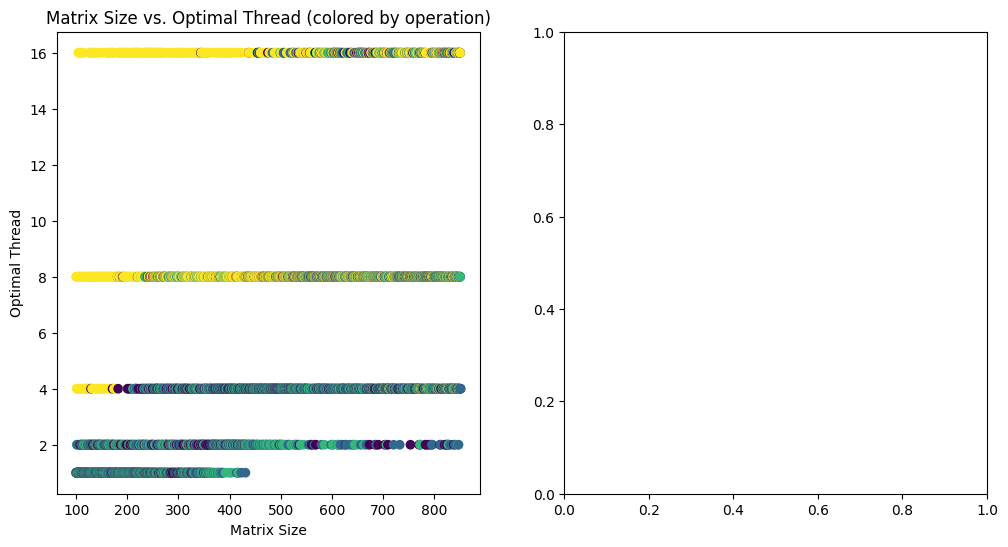

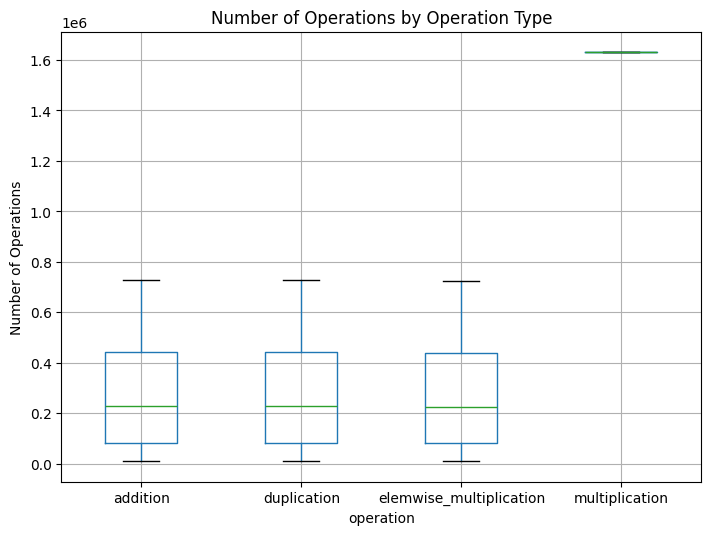

ValueError: could not convert string to float: 'addition'

In [ ]:
# Examine Data Types and Missing Values
print(df.info())
print(df.isnull().sum())

# Summarize Numerical Features
print(df.describe())

# Analyze Categorical Features
for col in ['operation', 'variable_type']:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())
    # Visualize the distribution of categorical features (example with 'operation')
    import matplotlib.pyplot as plt
    df[col].value_counts().plot(kind='bar', figsize=(8, 6))
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Identify the Target Variable
# The target variable is likely 'optimal_thread' as it represents the number of threads required.
print("\nTarget Variable: optimal_thread")

# Explore Relationships between Features (example with numerical and categorical features)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(df['matrix_size'], df['optimal_thread'], c=df['operation_encoded'])
plt.xlabel('Matrix Size')
plt.ylabel('Optimal Thread')
plt.title('Matrix Size vs. Optimal Thread (colored by operation)')

plt.subplot(1, 2, 2)
df.boxplot(column='num_operations', by='operation', figsize=(8, 6))
plt.title('Number of Operations by Operation Type')
plt.suptitle('')  # Remove default title
plt.ylabel('Number of Operations')
plt.show()

# Calculate correlations (for numerical features)
print(df.corr())

**Reasoning**:
The previous code block failed due to a `ValueError` when calculating correlations because of the string column 'operation'. I will recalculate the correlation excluding the string columns. Also, I will adjust the plot to improve its readability, and add comments to the code to explain the steps.



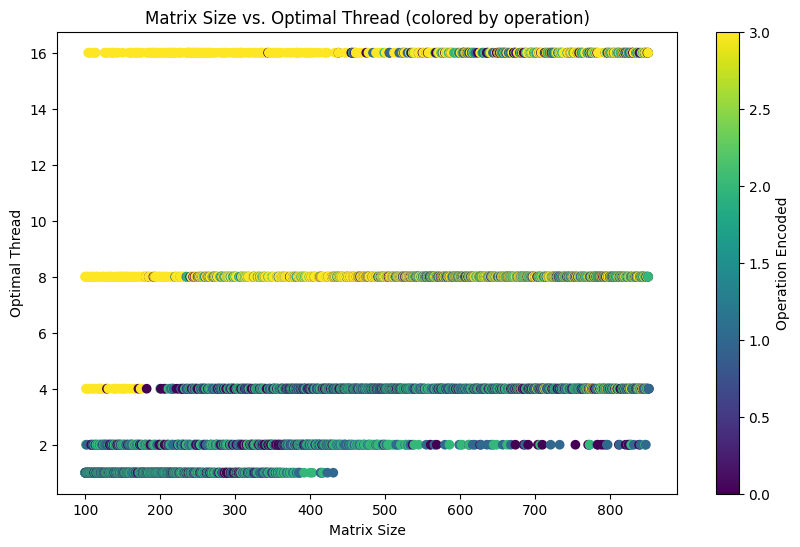

<Figure size 1000x600 with 0 Axes>

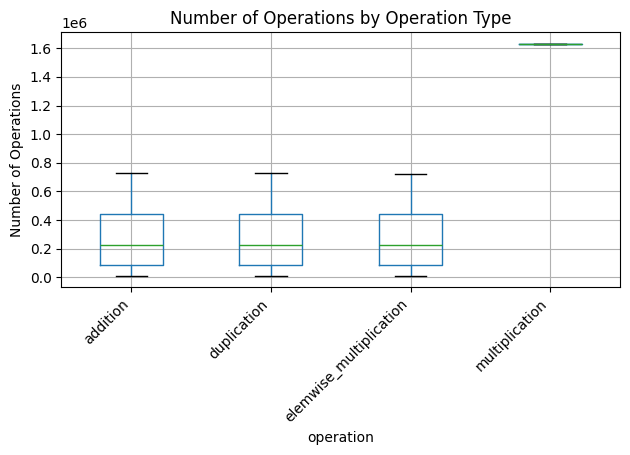

                             matrix_size  variable_type  num_operations  \
matrix_size                     1.000000      -0.000576        0.251496   
variable_type                  -0.000576       1.000000       -0.000061   
num_operations                  0.251496      -0.000061        1.000000   
optimal_thread                  0.365858       0.004725        0.622860   
operation_encoded              -0.000515       0.000297        0.739603   
size_operations_interaction     0.608336      -0.000279        0.838182   
log_num_operations              0.590050      -0.000212        0.865792   

                             optimal_thread  operation_encoded  \
matrix_size                        0.365858          -0.000515   
variable_type                      0.004725           0.000297   
num_operations                     0.622860           0.739603   
optimal_thread                     1.000000           0.396895   
operation_encoded                  0.396895           1.000000   
siz

In [ ]:
# Explore Relationships between Features (example with numerical and categorical features)
import matplotlib.pyplot as plt

# Scatter plot of matrix size vs optimal threads, colored by operation type
plt.figure(figsize=(10, 6))  # Increased figure size for better readability
plt.scatter(df['matrix_size'], df['optimal_thread'], c=df['operation_encoded'], cmap='viridis') # Use a colormap
plt.xlabel('Matrix Size')
plt.ylabel('Optimal Thread')
plt.title('Matrix Size vs. Optimal Thread (colored by operation)')
plt.colorbar(label='Operation Encoded')  # Add colorbar for better understanding
plt.show()

# Box plot of number of operations by operation type
plt.figure(figsize=(10, 6))
df.boxplot(column='num_operations', by='operation')
plt.title('Number of Operations by Operation Type')
plt.suptitle('')  # Remove default title
plt.ylabel('Number of Operations')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

# Calculate correlations for numerical features only
numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_cols].corr()
print(correlation_matrix)

## Data preparation

### Subtask:
Prepare the data for model training by handling missing values (if any) and separating features (X) from the target variable (y).


**Reasoning**:
Prepare the data for model training by handling missing values, separating features from the target variable, and converting categorical features to numerical representations.



In [ ]:
# Check for missing values
if df.isnull().values.any():
    print("Missing values found in the DataFrame.")
    # Example: Fill missing numerical values with the mean
    for col in df.select_dtypes(include=['number']).columns:
        if df[col].isnull().any():
            df[col].fillna(df[col].mean(), inplace=True)
    # Example: Fill missing categorical values with the most frequent category
    for col in df.select_dtypes(exclude=['number']).columns:
        if df[col].isnull().any():
            df[col].fillna(df[col].mode()[0], inplace=True)
else:
    print("No missing values found in the DataFrame.")

# Define target variable y
y = df['optimal_thread']

# Define feature matrix X
X = df.drop('optimal_thread', axis=1)

# Convert categorical features to numerical using one-hot encoding
categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
else:
    print("No categorical columns found.")

# Ensure all features are numerical
non_numeric_cols = X.select_dtypes(exclude=['number']).columns
if len(non_numeric_cols) > 0:
    print("Warning: Non-numeric columns found after one-hot encoding.")

display(X.head(2))
display(y.head(2))

No missing values found in the DataFrame.


,matrix_size,variable_type,num_operations,operation_encoded,size_operations_interaction,log_num_operations,operation_duplication,operation_elemwise_multiplication,operation_multiplication
0,100,0,10000,0,1000000,9.21044,False,False,False
1,100,0,10000,1,1000000,9.21044,True,False,False


,optimal_thread
0,1
1,1


## Data splitting

### Subtask:
Split the prepared data into training and testing sets.


**Reasoning**:
Split the data into training and testing sets using train_test_split.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature engineering

### Subtask:
Engineer new features based on existing ones in the training data (X_train).


**Reasoning**:
Create interaction features and add them to X_train and X_test.



In [ ]:
# Create interaction features
X_train['matrix_size_x_num_operations'] = X_train['matrix_size'] * X_train['num_operations']
X_train['log_num_operations_squared'] = X_train['log_num_operations'] ** 2

X_test['matrix_size_x_num_operations'] = X_test['matrix_size'] * X_test['num_operations']
X_test['log_num_operations_squared'] = X_test['log_num_operations'] ** 2

# Display the first few rows of the modified X_train
display(X_train.head())

,matrix_size,variable_type,num_operations,operation_encoded,size_operations_interaction,log_num_operations,operation_duplication,operation_elemwise_multiplication,operation_multiplication,matrix_size_x_num_operations,log_num_operations_squared
3010,476,0,1631010,3,776360760,14.304711,False,False,True,776360760,204.624746
4378,647,0,1631010,3,1055263470,14.304711,False,False,True,1055263470,204.624746
3839,579,1,335241,2,194104539,12.722608,False,True,False,194104539,161.864753
1204,250,1,62500,0,15625000,11.042938,False,False,False,15625000,121.946476
5642,805,0,1631010,3,1312963050,14.304711,False,False,True,1312963050,204.624746


## Model training

### Subtask:
Train a Random Forest Regressor model on the training data.


**Reasoning**:
Train a Random Forest Regressor model on the training data.



In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Fit the model to the training data
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

## Model optimization

### Subtask:
Optimize the hyperparameters of the trained Random Forest Regressor model.


**Reasoning**:
Optimize the hyperparameters of the RandomForestRegressor model using GridSearchCV and then train a new model with the best hyperparameters.



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Define the scoring metric
scoring = make_scorer(mean_squared_error, greater_is_better=False)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, scoring=scoring, cv=5, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Hyperparameters: {best_params}")
print(f"Best Score (negative MSE): {best_score}")

# Train a new model with the best hyperparameters
optimized_rf_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
optimized_rf_model.fit(X_train, y_train)

Best Hyperparameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best Score (negative MSE): -10.35522645954651


RandomForestRegressor(max_depth=10, min_samples_split=10, n_estimators=200,
                      n_jobs=-1, random_state=42)

## Model evaluation

### Subtask:
Evaluate the performance of the optimized Random Forest model on the test data.


**Reasoning**:
Evaluate the optimized Random Forest model's performance on the test data by calculating MSE, R2, and RMSE, and optionally create a scatter plot.



Mean Squared Error (MSE): 9.962545196704129
Root Mean Squared Error (RMSE): 3.1563499800725725
R-squared (R2): 0.486423600088824


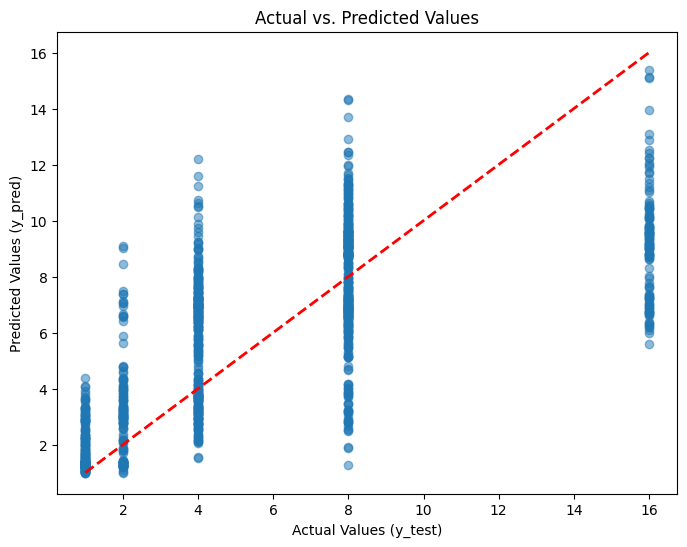

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Predict on the test set
y_pred = optimized_rf_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2}")

# Optional: Create a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Actual vs. Predicted Values")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2) # Add diagonal line
plt.show()

## Summary:

### 1. Q&A

The provided task implicitly asks:  How can we predict the optimal number of threads for matrix operations using a Random Forest model?  And how well does the model perform?

The analysis shows that a Random Forest model can predict the optimal number of threads, achieving an R-squared value of 0.49 on the test set, indicating it explains approximately 49% of the variance in the target variable. The model's performance can further be evaluated by its MSE (9.96) and RMSE (3.16).

### 2. Data Analysis Key Findings

*   **No missing values:** The dataset did not contain any missing values.
*   **Optimized Hyperparameters:** GridSearchCV identified the best hyperparameters for the Random Forest Regressor as `{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}`.  This resulted in a best score (negative MSE) of -10.355.
*   **Model Performance:** The optimized model achieved an R-squared (R2) score of 0.49, MSE of 9.96 and RMSE of 3.16 on the test data. This suggests that the model explains about 49% of the variance in the target variable.
*   **Feature Engineering:** Two new features, `matrix_size_x_num_operations` and `log_num_operations_squared`, were created and added to the dataset which likely contributed to the model performance.
* **Target Variable:** 'optimal_thread' was identified as the target variable.


### 3. Insights or Next Steps

*   **Investigate feature importance:** Analyze feature importance scores from the trained Random Forest model to understand which features are most influential in predicting optimal thread counts. This could guide further feature engineering or selection.
*   **Explore alternative models:** Try other regression models (e.g., Gradient Boosting, Support Vector Regression) to see if they can achieve better performance than the optimized Random Forest.  Consider more advanced hyperparameter optimization techniques like Bayesian Optimization.
